# Sample-level exploratory data analysis 

## Purpose 
This notebook explores the rhabdomyosarcoma dataset at the sample level. The goal is to understand the distribution of clinical and genomic variables, identify potential outliers, examine relationships between variables, and determine which visualizations should be incorporated into the interactive Streamlit application. Because some patients contribute multiple tumor samples, this notebook focuses on describing the data rather than making patient-level statistical inferences.

## Objectives 
* Load the cleaned sample-level dataset.
* Explore distributions of numeric variables.
* Examine relationships between continuous variables.
* Identify potential outliers.
* Calculate correlations among quantitative variables.
* Explore categorical variables such as sex and sample type.
* Identify visualizations that should become interactive components of the Streamlit application.

# Imports 

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

# Load cleaned data

In [2]:
PROJECT_DIR = Path.cwd().parent

DATA_FILE = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "sample_level_cleaned.tsv"
)

df = pd.read_csv(
    DATA_FILE,
    sep="\t"
)

df.head()

,Study ID,Patient ID,Sample ID,Age at Which Sequencing was Reported (Years),Cancer Type,Cancer Type Detailed,Ethnicity Category,Fraction Genome Altered,Gene Panel,Institute Source,...,Race Category,Sample Class,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Somatic Status,TMB (nonsynonymous),Tumor Purity,Event
0,soft_tissue_msk_2023,P-0006113,P-0006113-T01-IM5,18.0,Soft Tissue Sarcoma,Alveolar Rhabdomyosarcoma,"Spanish NOS; Hispanic NOS, Latino NOS",0.0844,IMPACT410,MSKCC,...,WHITE,Tumor,2,949,Primary,Male,Matched,0.978720,80.0,1.0
1,soft_tissue_msk_2023,P-0006113,P-0006113-T02-IM6,18.0,Soft Tissue Sarcoma,Alveolar Rhabdomyosarcoma,"Spanish NOS; Hispanic NOS, Latino NOS",0.3861,IMPACT468,MSKCC,...,WHITE,Tumor,2,743,Metastasis,Male,Matched,0.864698,30.0,1.0
2,soft_tissue_msk_2023,P-0013120,P-0013120-T04-IM6,19.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.1217,IMPACT468,MSKCC,...,WHITE,Tumor,2,727,Metastasis,Female,Matched,0.000000,30.0,1.0
3,soft_tissue_msk_2023,P-0013120,P-0013120-T06-IM6,20.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.2839,IMPACT468,NaN,...,WHITE,Tumor,2,666,Metastasis,Female,Matched,0.000000,70.0,1.0
4,soft_tissue_msk_2023,P-0018770,P-0018770-T02-IM6,18.0,Soft Tissue Sarcoma,Embryonal Rhabdomyosarcoma,Non-Spanish; Non-Hispanic,0.6574,IMPACT468,MSKCC,...,ASIAN-FAR EAST/INDIAN SUBCONT,Tumor,2,651,Primary,Male,Matched,0.864698,70.0,1.0


# Dataset dimensions 

In [3]:
print(f"Samples: {len(df)}")
print(f"Patients: {df['Patient ID'].nunique()}")
print(f"Variables: {df.shape[1]}")

Samples: 42
Patients: 20
Variables: 28


# Identify numeric variables 

In [4]:
numeric_columns = (
    df
    .select_dtypes(include=np.number)
    .columns
    .tolist()
)

numeric_columns

['Age at Which Sequencing was Reported (Years)',
 'Fraction Genome Altered',
 'MSI Score',
 'Mutation Count',
 'Overall Survival (Months)',
 'Number of Samples Per Patient',
 'Sample coverage',
 'TMB (nonsynonymous)',
 'Tumor Purity',
 'Event']

# Summary Statistics 

In [5]:
summary = (
    df[numeric_columns]
    .describe()
    .T
)

summary

,count,mean,std,min,25%,50%,75%,max
Age at Which Sequencing was Reported (Years),39.0,20.871795,8.013737,18.000,18.00000,18.000000,19.500000,54.000000
Fraction Genome Altered,42.0,0.313193,0.227348,0.000,0.16355,0.273600,0.433475,0.973600
MSI Score,40.0,1.216000,1.667201,0.000,0.20000,0.595000,1.452500,8.710000
Mutation Count,30.0,2.600000,1.588754,1.000,1.00000,2.500000,3.000000,7.000000
Overall Survival (Months),40.0,27.450400,16.647167,3.649,14.98400,31.890000,37.570000,69.008000
Number of Samples Per Patient,42.0,2.142857,0.354169,2.000,2.00000,2.000000,2.000000,3.000000
Sample coverage,42.0,617.071429,206.892383,203.000,487.50000,634.500000,725.000000,1001.000000
TMB (nonsynonymous),42.0,1.528860,1.460685,0.000,0.00000,1.309707,2.461042,5.742431
Tumor Purity,38.0,56.052632,20.604313,10.000,40.00000,60.000000,70.000000,90.000000
Event,40.0,0.550000,0.503831,0.000,0.00000,1.000000,1.000000,1.000000


# Interactive Histogram 

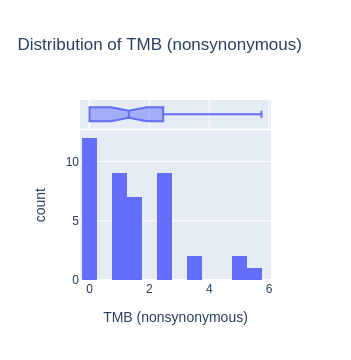

In [6]:
variable = "TMB (nonsynonymous)"

fig = px.histogram(
    df,
    x=variable,
    nbins=15,
    marginal="box",
    title=f"Distribution of {variable}"
)

fig.show()

# Boxplots of every numeric variable

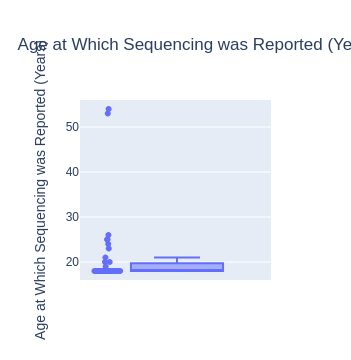

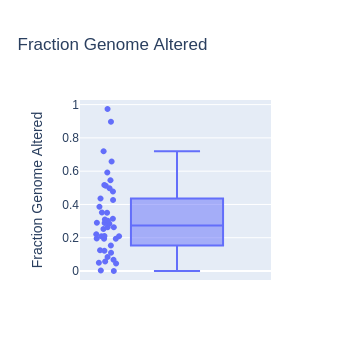

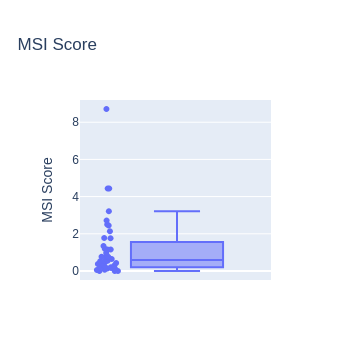

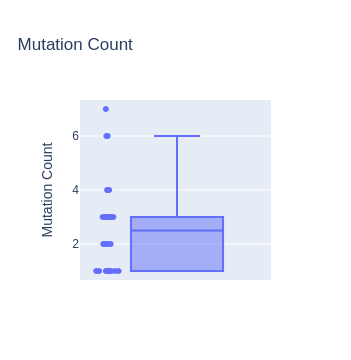

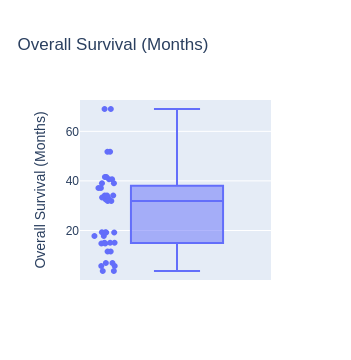

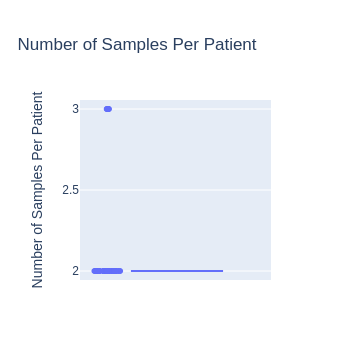

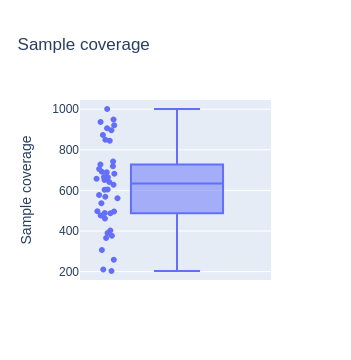

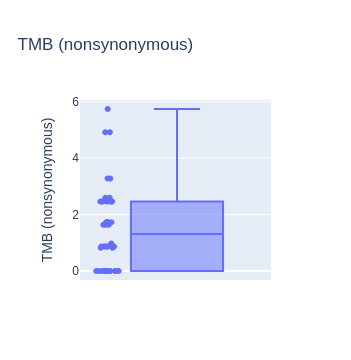

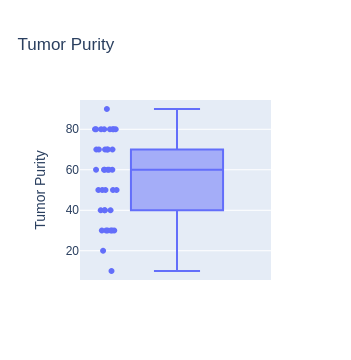

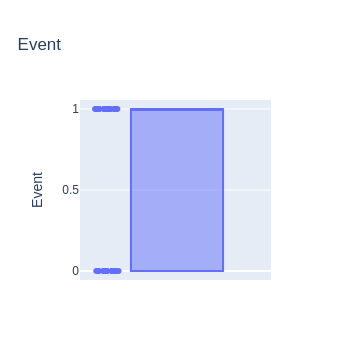

In [7]:
for variable in numeric_columns:

    fig = px.box(
        df,
        y=variable,
        points="all",
        title=variable
    )

    fig.show()

# Scatterplots

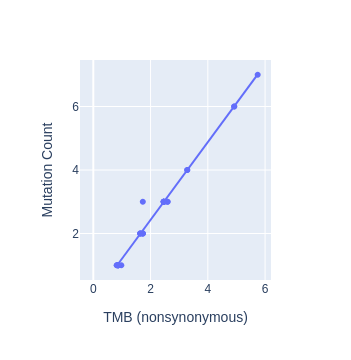

In [8]:
fig = px.scatter(

    df,

    x="TMB (nonsynonymous)",

    y="Mutation Count",

    hover_name="Patient ID",

    hover_data=["Sample ID"],

    trendline="ols"

)

fig.show()

# Correlation Matrix

In [9]:
corr = (
    df[numeric_columns]
    .corr(numeric_only=True)
)

corr

,Age at Which Sequencing was Reported (Years),Fraction Genome Altered,MSI Score,Mutation Count,Overall Survival (Months),Number of Samples Per Patient,Sample coverage,TMB (nonsynonymous),Tumor Purity,Event
Age at Which Sequencing was Reported (Years),1.000000,0.445836,0.606402,-0.149504,0.159595,0.024879,-0.205120,0.023471,0.040116,-0.144984
Fraction Genome Altered,0.445836,1.000000,0.412328,-0.151885,0.017148,-0.113669,-0.043679,0.173846,0.254105,-0.149871
MSI Score,0.606402,0.412328,1.000000,0.404206,-0.132696,-0.015566,-0.384196,0.476339,0.445019,-0.052138
Mutation Count,-0.149504,-0.151885,0.404206,1.000000,-0.436255,-0.192055,-0.470081,0.993599,0.198590,0.097733
Overall Survival (Months),0.159595,0.017148,-0.132696,-0.436255,1.000000,-0.073893,0.245338,-0.212534,-0.097828,-0.176177
Number of Samples Per Patient,0.024879,-0.113669,-0.015566,-0.192055,-0.073893,1.000000,-0.118308,0.033727,0.113864,0.379980
Sample coverage,-0.205120,-0.043679,-0.384196,-0.470081,0.245338,-0.118308,1.000000,-0.499092,0.040639,0.090925
TMB (nonsynonymous),0.023471,0.173846,0.476339,0.993599,-0.212534,0.033727,-0.499092,1.000000,0.222016,0.122102
Tumor Purity,0.040116,0.254105,0.445019,0.198590,-0.097828,0.113864,0.040639,0.222016,1.000000,0.101269
Event,-0.144984,-0.149871,-0.052138,0.097733,-0.176177,0.379980,0.090925,0.122102,0.101269,1.000000


# Interactive Heatmap 

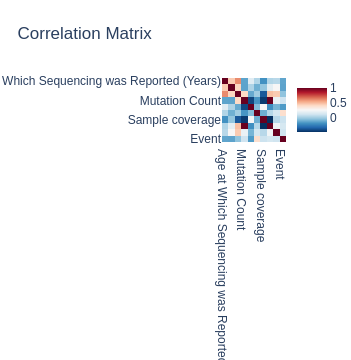

In [10]:
fig = px.imshow(

    corr,

    text_auto=True,

    aspect="auto",

    color_continuous_scale="RdBu_r",

    title="Correlation Matrix"

)

fig.show()

# Missing data visualization 

In [11]:
missing = (
    df
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

Metastatic Site                                 27
Mutation Count                                  12
Tumor Purity                                     4
Age at Which Sequencing was Reported (Years)     3
Institute Source                                 3
Sex                                              2
MSI Score                                        2
Race Category                                    2
MSI Type                                         2
Overall Survival (Months)                        2
Event                                            2
Ethnicity Category                               2
Overall Survival Status                          2
dtype: int64

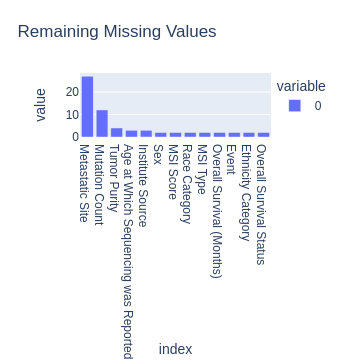

In [12]:
fig = px.bar(

    missing,

    title="Remaining Missing Values"

)

fig.show()

# Explore categorical variables 

In [13]:
categorical_columns = (
    df
    .select_dtypes(exclude=np.number)
    .columns
)

categorical_columns

Index(['Study ID', 'Patient ID', 'Sample ID', 'Cancer Type',
       'Cancer Type Detailed', 'Ethnicity Category', 'Gene Panel',
       'Institute Source', 'Metastatic Site', 'MSI Type', 'Oncotree Code',
       'Overall Survival Status', 'Primary Tumor Site', 'Race Category',
       'Sample Class', 'Sample Type', 'Sex', 'Somatic Status'],
      dtype='object')

# Frequency Tables

In [14]:
for variable in categorical_columns:

    print(variable)

    display(df[variable].value_counts(dropna=False))

    print("-"*60)

Study ID


Study ID
soft_tissue_msk_2023    42
Name: count, dtype: int64

------------------------------------------------------------
Patient ID


Patient ID
P-0060318    3
P-0035844    3
P-0006113    2
P-0013120    2
P-0019531    2
P-0018770    2
P-0028971    2
P-0022317    2
P-0045478    2
P-0048073    2
P-0050430    2
P-0033453    2
P-0051132    2
P-0051453    2
P-0063459    2
P-0068164    2
P-0069477    2
P-0073133    2
P-0074869    2
P-0077663    2
Name: count, dtype: int64

------------------------------------------------------------
Sample ID


...

------------------------------------------------------------
Sex


Sex
Male      23
Female    17
NaN        2
Name: count, dtype: int64

------------------------------------------------------------
Somatic Status


Somatic Status
Matched    42
Name: count, dtype: int64

------------------------------------------------------------


# Bar Chart of Categorical Variables

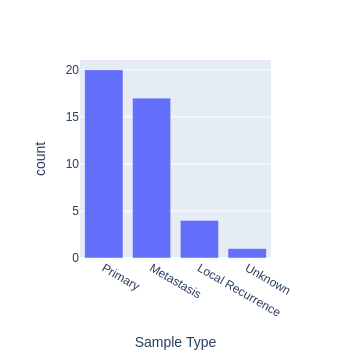

In [15]:
variable = "Sample Type"

fig = px.bar(

    df[variable]
    .value_counts()
    .reset_index(),

    x=variable,

    y="count"

)

fig.show()

# TMB grouped by categorical variables

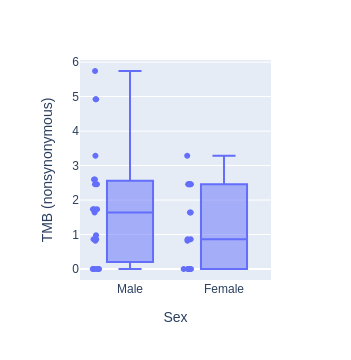

In [16]:
# Example
fig = px.box(

    df,

    x="Sex",

    y="TMB (nonsynonymous)",

    points="all"

)

fig.show()

# Pairwise scatter matrix

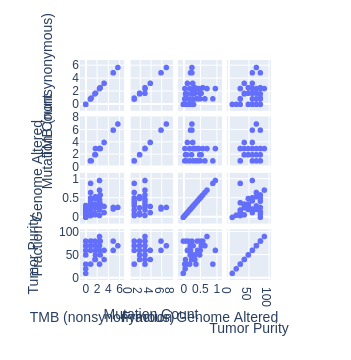

In [17]:
variables = [

    "TMB (nonsynonymous)",

    "Mutation Count",

    "Fraction Genome Altered",

    "Tumor Purity"

]

fig = px.scatter_matrix(

    df,

    dimensions=variables,

    hover_name="Patient ID"

)

fig.show()

# Export Summary Statistics

In [18]:
OUTPUT_DIR = (
    PROJECT_DIR
    / "results"
)

OUTPUT_DIR.mkdir(exist_ok=True)

summary.to_csv(
    OUTPUT_DIR / "summary_statistics.csv"
)

corr.to_csv(
    OUTPUT_DIR / "correlation_matrix.csv"
)

# Conclusions 

Key Findings

• Distribution of TMB across all samples

• Distribution of mutation counts

• Presence of outliers

• Strongest correlations among genomic variables

• Variables that will become Streamlit filters

• Variables appropriate for patient-level aggregation